# Predicting Student Health Risk — Kaggle Playground Series S6E7

**대회 개요**
- 목표: 학생의 건강 관련 라이프스타일 지표로부터 `health_condition`(건강 상태)을 예측하는 3-클래스 분류 문제
- 클래스: `fit`, `at-risk`, `unhealthy`
- 평가지표: **Balanced Accuracy** (클래스별 recall의 평균) → 클래스 불균형에 민감하지 않은 지표
- 제출 형식: `id, health_condition` (sample_submission.csv 참고)
- 데이터: train 690,088행 / test 295,753행, 14개 피처(수치형 7 + 범주형 6) + id
- 참고: 이 노트북은 EDA → 모델링 → Validation 순서로 구성됩니다.

**파이프라인 순서**
1. EDA (데이터 구조, 결측치, 분포, 클래스별 특성 파악)
2. 전처리 & 모델링
3. Validation (Balanced Accuracy 기준)
4. 제출 파일 생성


## 1. EDA (Exploratory Data Analysis)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid')
import matplotlib.font_manager as fm
for _p in ['/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
           '/System/Library/Fonts/AppleSDGothicNeo.ttc',
           'C:/Windows/Fonts/malgun.ttf']:
    if os.path.exists(_p):
        fm.fontManager.addfont(_p)
        plt.rcParams['font.family'] = fm.FontProperties(fname=_p).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = '.'  # 노트북과 같은 폴더에 train.csv / test.csv / sample_submission.csv 위치
RANDOM_STATE = 42

train = pd.read_csv(f'{DATA_DIR}/train.csv')
test = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')

TARGET = 'health_condition'
ID_COL = 'id'
NUM_COLS = ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure',
            'step_count', 'exercise_duration', 'water_intake']
CAT_COLS = ['diet_type', 'stress_level', 'sleep_quality',
            'physical_activity_level', 'smoking_alcohol', 'gender']

print('train shape:', train.shape)
print('test shape :', test.shape)
print('sample_submission shape:', sample_sub.shape)


train shape: (690088, 15)
test shape : (295753, 14)
sample_submission shape: (295753, 2)


### 1.1 데이터 구조 확인

In [2]:
train.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 non-null  object 
 14  gend

In [4]:
sample_sub.head()

,id,health_condition
0,690088,at-risk
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,at-risk


**확인 사항**
- train에만 존재하는 컬럼: `health_condition` (타겟)
- id는 train/test 모두 유일하며, train-test 간 id 중복 없음
- 완전 중복행(id 제외)은 0건


In [5]:
print('train id unique:', train[ID_COL].is_unique)
print('test id unique :', test[ID_COL].is_unique)
print('train/test id overlap:', len(set(train[ID_COL]) & set(test[ID_COL])))
print('duplicate rows (excluding id):', train.drop(columns=[ID_COL]).duplicated().sum())


train id unique: True
test id unique : True
train/test id overlap: 0
duplicate rows (excluding id): 0


### 1.2 타겟(health_condition) 분포 — 클래스 불균형 확인

,count,ratio
health_condition,,
at-risk,592561,0.8587
unhealthy,57724,0.0836
fit,39803,0.0577


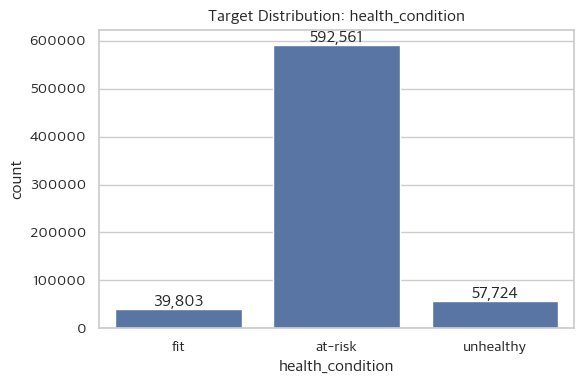

In [6]:
target_counts = train[TARGET].value_counts()
target_ratio = train[TARGET].value_counts(normalize=True)
display(pd.DataFrame({'count': target_counts, 'ratio': target_ratio.round(4)}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, ax=ax, order=['fit', 'at-risk', 'unhealthy'])
ax.set_title('Target Distribution: health_condition')
ax.set_ylabel('count')
for i, v in enumerate(target_counts.reindex(['fit', 'at-risk', 'unhealthy']).values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


> **인사이트**: `at-risk`가 전체의 약 86%를 차지하는 심한 불균형 데이터입니다. 단순 accuracy로는 다수 클래스만 맞혀도 높은 점수가 나오므로, 대회가 **balanced accuracy**(클래스별 recall 평균)를 쓰는 이유가 여기 있습니다. → 모델링 시 class weight, 혹은 임계값/샘플링 조정이 필요할 가능성이 높습니다.

### 1.3 결측치 분석

,train_missing_%,test_missing_%
stress_level,12.00,12.00
sleep_duration,11.01,11.01
sleep_quality,8.45,8.45
calorie_expenditure,7.66,7.66
water_intake,6.30,6.30
physical_activity_level,5.31,5.31
smoking_alcohol,4.14,4.14
gender,3.10,3.10
step_count,2.02,2.02
bmi,2.01,2.01


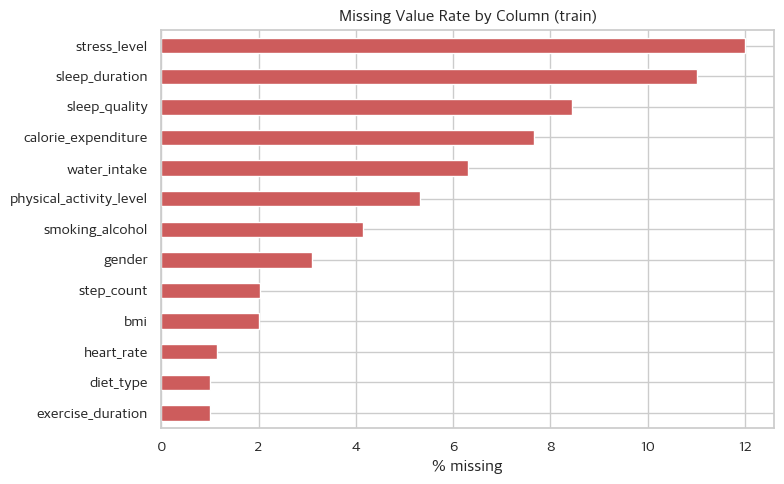

In [7]:
missing_train = train.isnull().mean().mul(100).round(2).rename('train_missing_%')
missing_test = test.isnull().mean().mul(100).round(2).rename('test_missing_%')
missing_df = pd.concat([missing_train, missing_test], axis=1).sort_values('train_missing_%', ascending=False)
missing_df = missing_df[missing_df['train_missing_%'] > 0]
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 5))
missing_df['train_missing_%'].sort_values().plot(kind='barh', ax=ax, color='indianred')
ax.set_title('Missing Value Rate by Column (train)')
ax.set_xlabel('% missing')
plt.tight_layout()
plt.show()


> **인사이트**: 거의 모든 피처(수치형·범주형)에 1~12% 수준의 결측치가 있고, train/test의 결측 비율이 거의 동일합니다 → 동일한 생성 프로세스로 만들어진 데이터로 보이며, 별도의 MCAR/MNAR 패턴 조사보다는 일관된 결측치 처리 전략(대치 또는 트리 모델의 native 처리)이 필요합니다. 타겟(health_condition)에는 결측치가 없습니다.

### 1.4 수치형 피처 분포

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


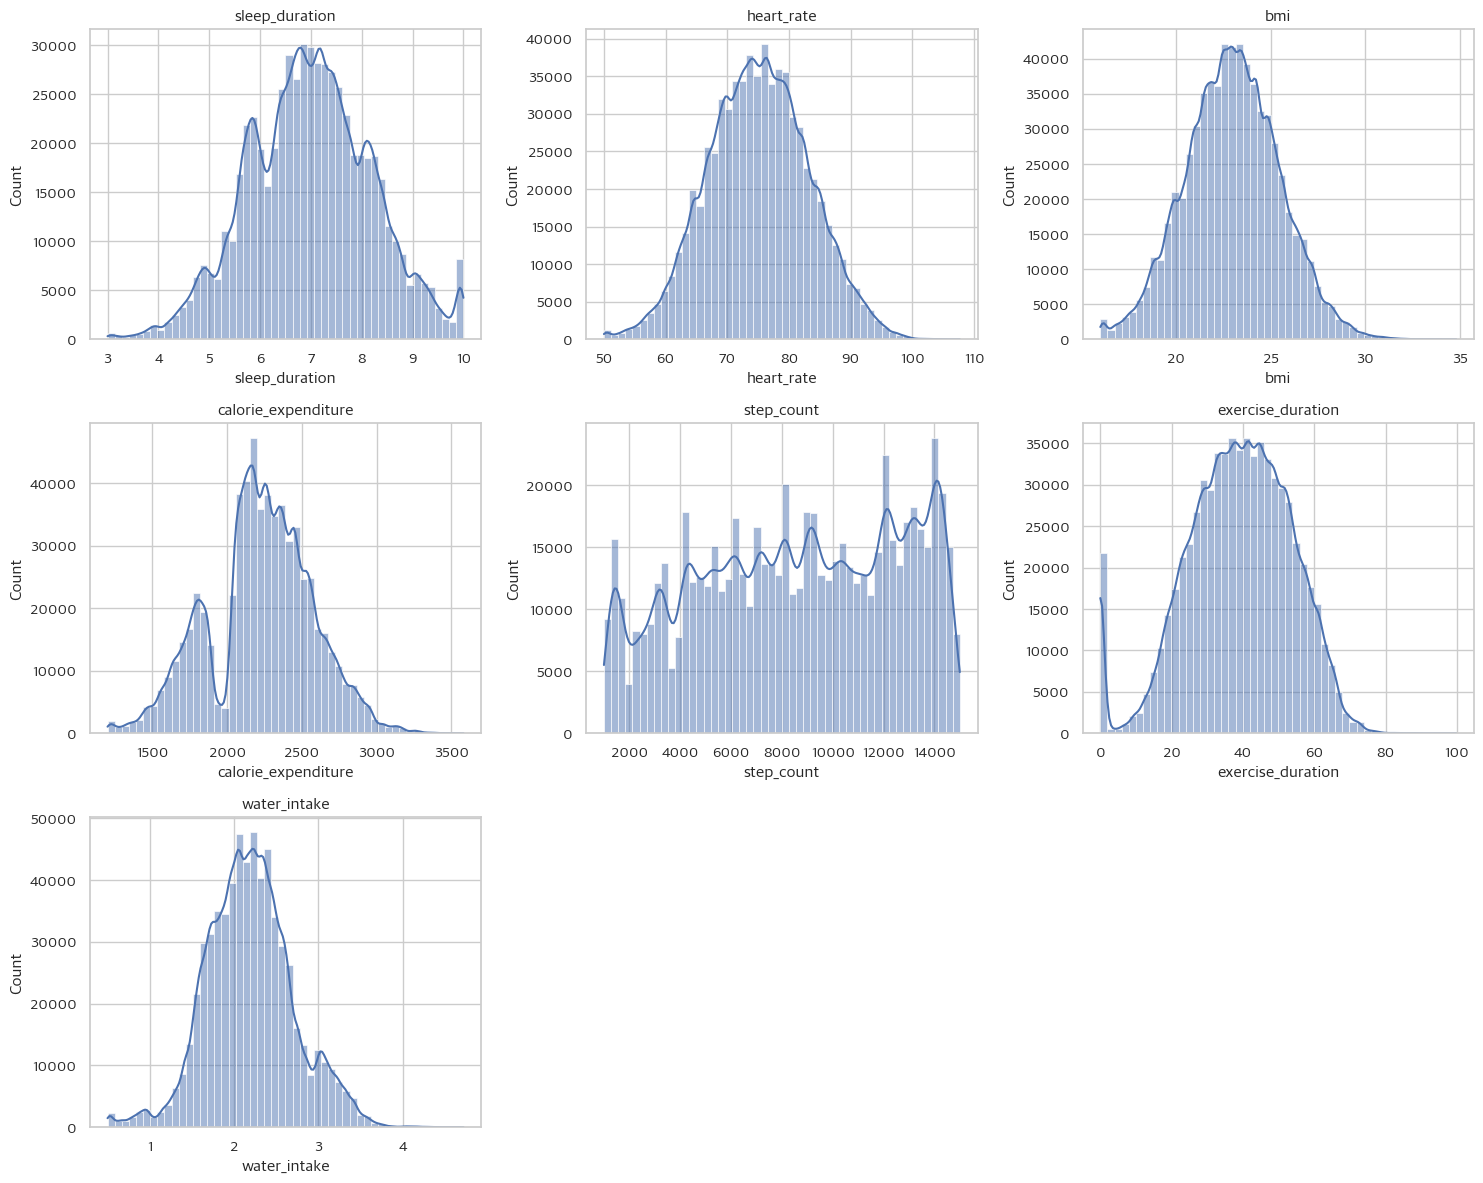

In [8]:
display(train[NUM_COLS].describe().T)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, c in enumerate(NUM_COLS):
    sns.histplot(train[c].dropna(), kde=True, ax=axes[i], bins=50)
    axes[i].set_title(c)
for j in range(len(NUM_COLS), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


### 1.5 범주형 피처 분포

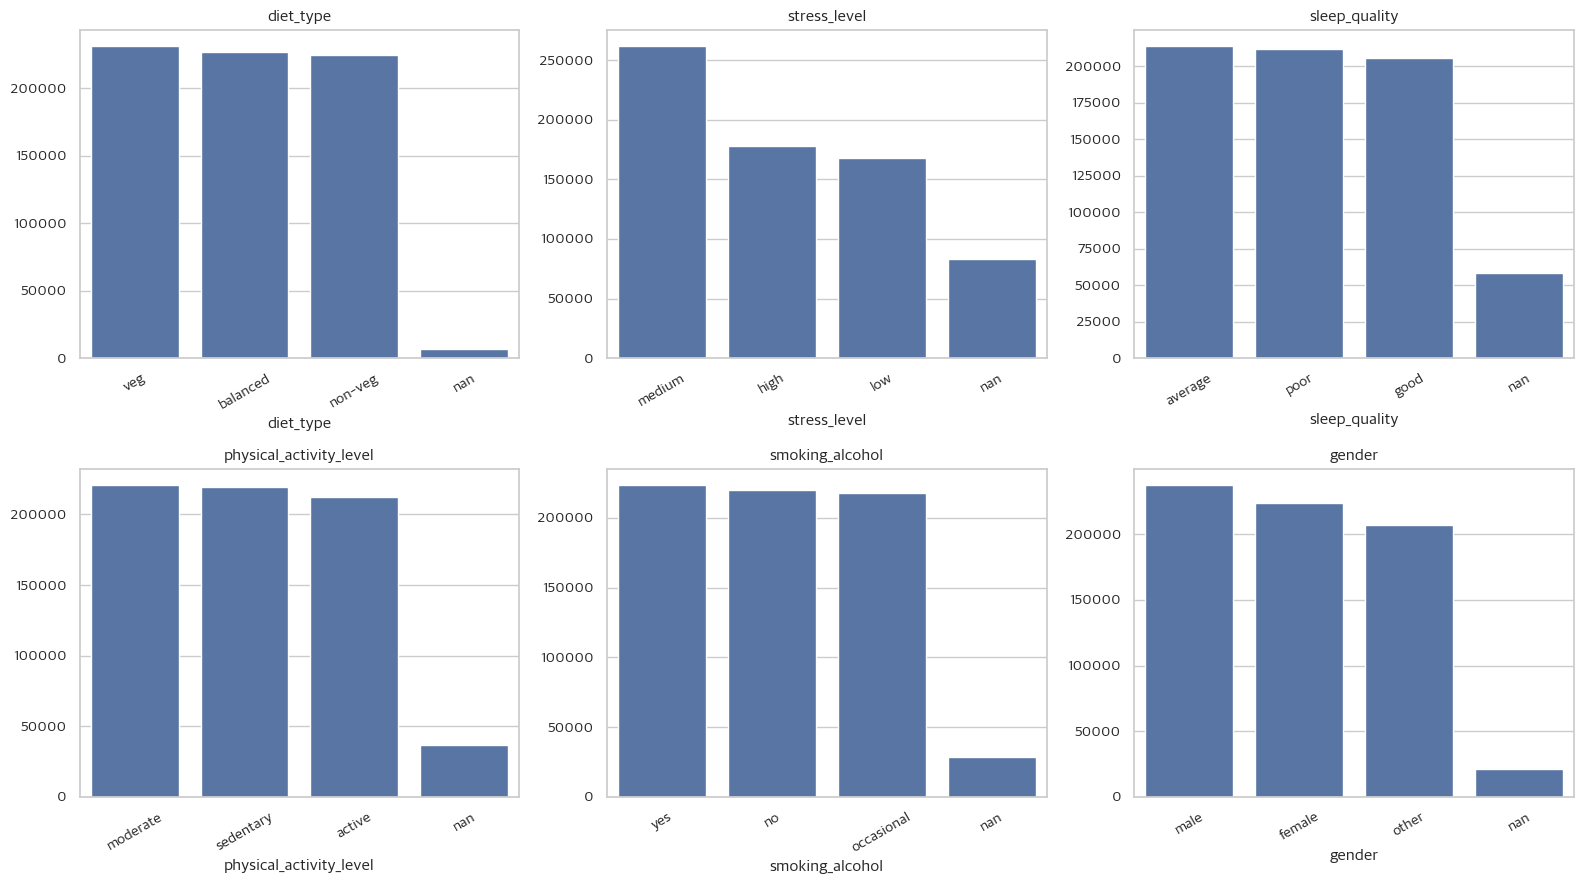

--- diet_type (3 unique) ---
diet_type
veg         0.335
balanced    0.329
non-veg     0.326
NaN         0.010
Name: proportion, dtype: float64

--- stress_level (3 unique) ---
stress_level
medium    0.379
high      0.258
low       0.243
NaN       0.120
Name: proportion, dtype: float64

--- sleep_quality (3 unique) ---
sleep_quality
average    0.310
poor       0.307
good       0.298
NaN        0.085
Name: proportion, dtype: float64

--- physical_activity_level (3 unique) ---
physical_activity_level
moderate     0.320
sedentary    0.318
active       0.308
NaN          0.053
Name: proportion, dtype: float64

--- smoking_alcohol (3 unique) ---
smoking_alcohol
yes           0.324
no            0.318
occasional    0.316
NaN           0.041
Name: proportion, dtype: float64

--- gender (3 unique) ---
gender
male      0.345
female    0.325
other     0.300
NaN       0.031
Name: proportion, dtype: float64



In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, c in enumerate(CAT_COLS):
    vc = train[c].value_counts(dropna=False)
    sns.barplot(x=vc.index.astype(str), y=vc.values, ax=axes[i])
    axes[i].set_title(c)
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

for c in CAT_COLS:
    print(f'--- {c} ({train[c].nunique(dropna=True)} unique) ---')
    print(train[c].value_counts(dropna=False, normalize=True).round(3))
    print()


> **인사이트**: 범주형 피처는 대부분 2~3개 수준이 비교적 고르게 분포되어 있습니다(합성 데이터 특성). 카디널리티가 낮아 원-핫/레이블 인코딩 모두 무리 없이 적용 가능합니다.

### 1.6 클래스별 수치형 피처 비교

health_condition,at-risk,fit,unhealthy
sleep_duration,7.086467,7.954311,5.366118
heart_rate,75.100534,74.803742,75.256903
bmi,22.949591,21.828544,24.122660
calorie_expenditure,2214.943466,2363.992052,2245.420223
step_count,8406.705910,11651.307024,8670.234090
exercise_duration,37.964960,50.042381,39.044280
water_intake,2.189130,2.179176,2.188961


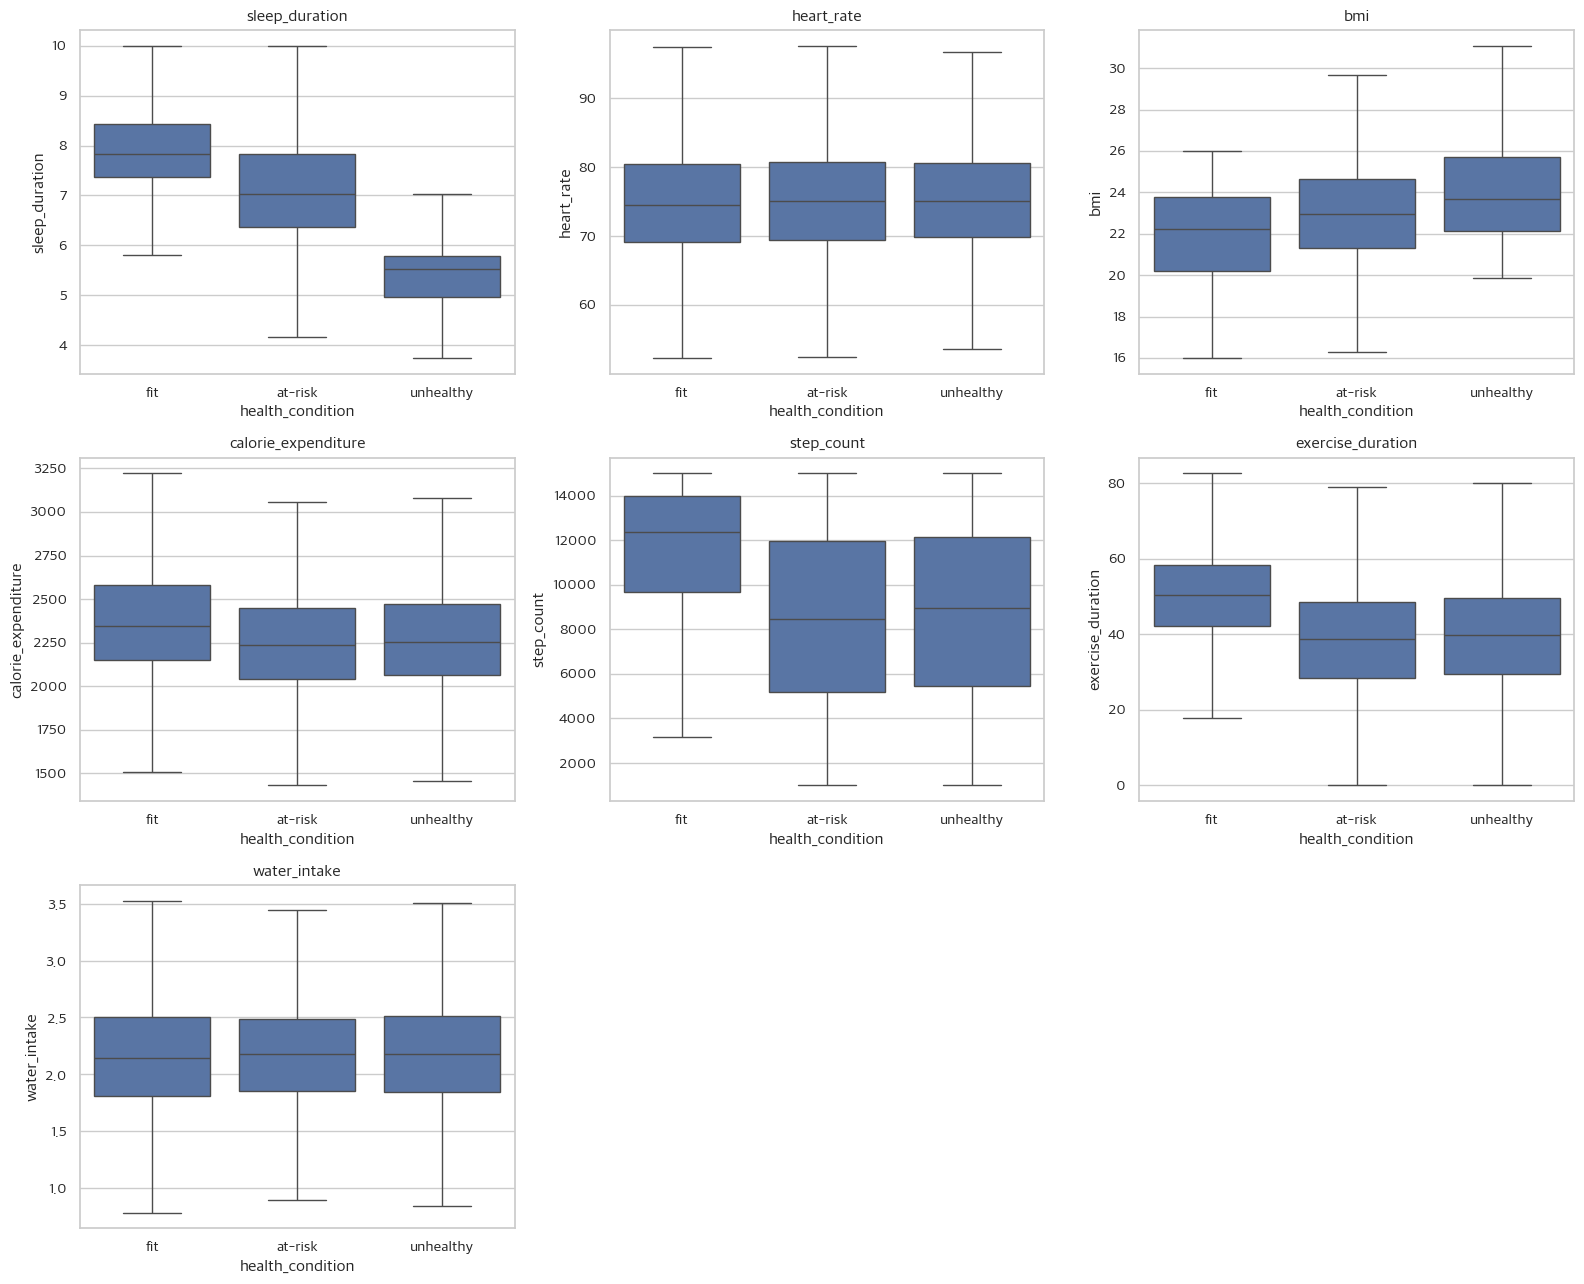

In [10]:
class_means = train.groupby(TARGET)[NUM_COLS].mean().T
display(class_means)

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()
order = ['fit', 'at-risk', 'unhealthy']
for i, c in enumerate(NUM_COLS):
    sns.boxplot(data=train, x=TARGET, y=c, order=order, ax=axes[i], showfliers=False)
    axes[i].set_title(c)
for j in range(len(NUM_COLS), len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


> **인사이트 (클래스별 차이가 뚜렷한 피처)**
> - `sleep_duration`: fit(7.95) > at-risk(7.09) > unhealthy(5.37) — 수면시간이 짧을수록 unhealthy 경향
> - `step_count`, `exercise_duration`: fit 그룹이 뚜렷하게 높음 → 활동량과 건강 상태의 관계
> - `bmi`: unhealthy 그룹이 가장 높음(24.1) → fit(21.8)
> - `heart_rate`, `water_intake`: 클래스 간 평균 차이가 거의 없어 예측력이 낮을 가능성 → 모델링 단계에서 feature importance로 재확인 필요


### 1.7 클래스별 범주형 피처 비교

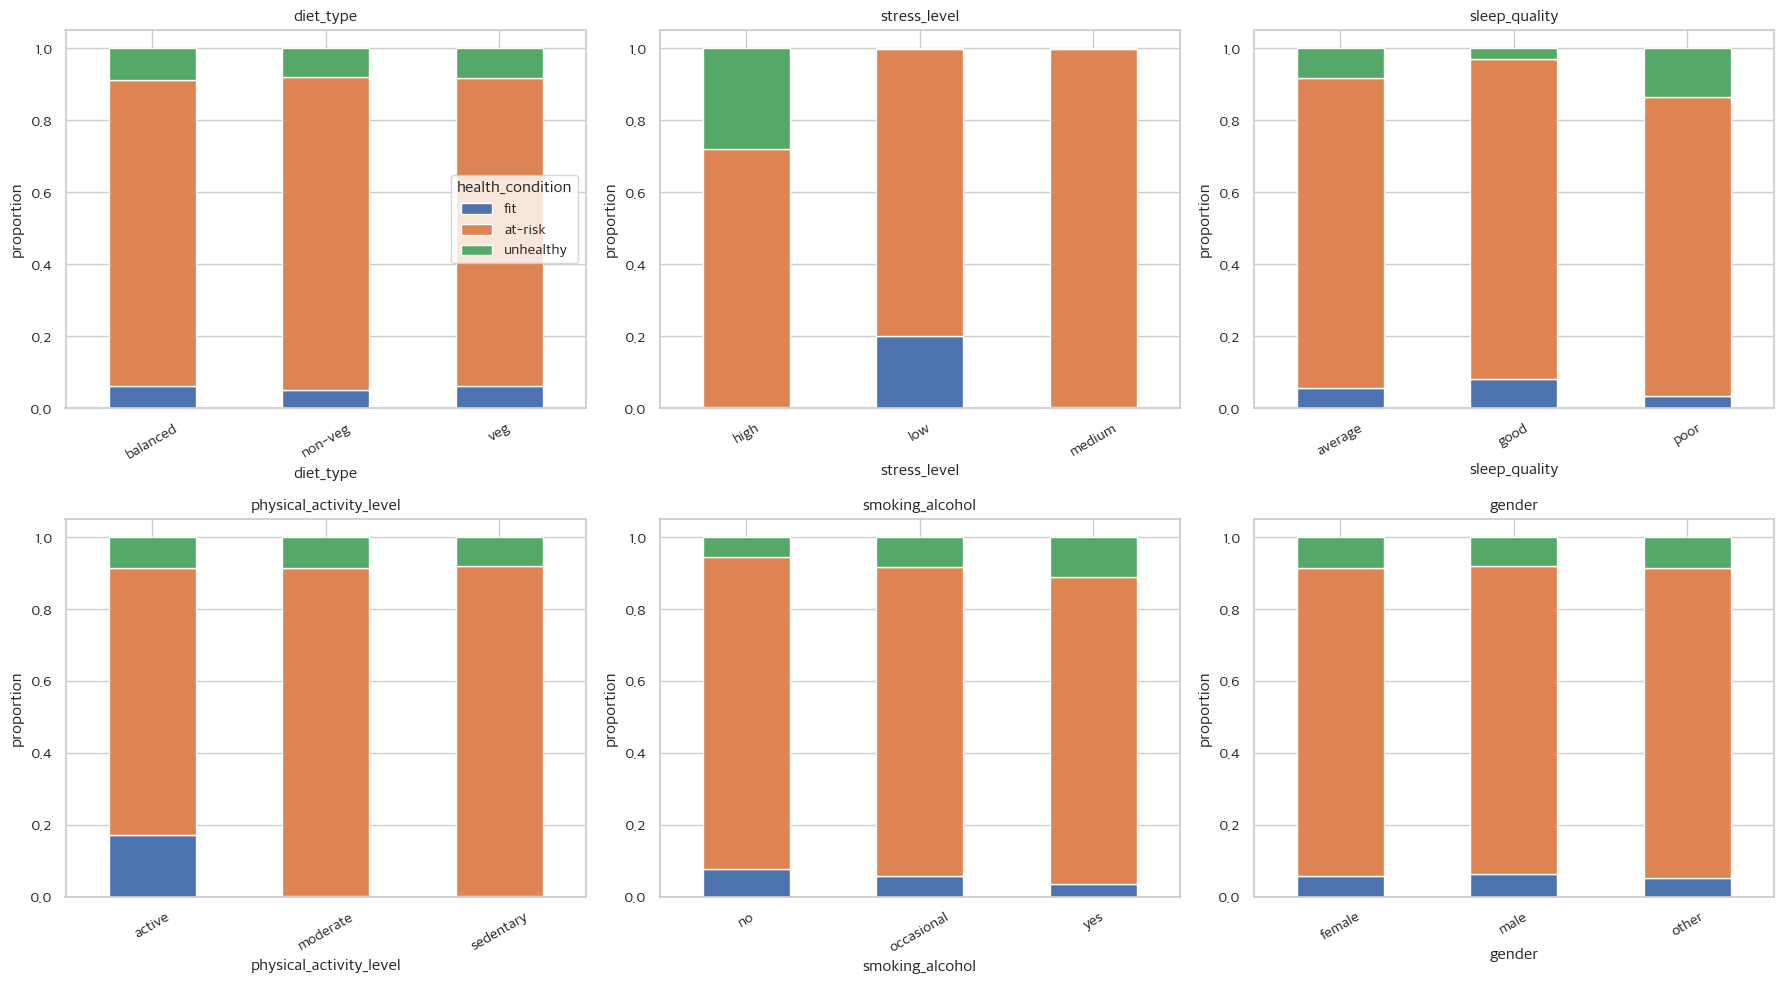

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, c in enumerate(CAT_COLS):
    ct = pd.crosstab(train[c], train[TARGET], normalize='index')[order]
    ct.plot(kind='bar', stacked=True, ax=axes[i], legend=(i == 0))
    axes[i].set_title(c)
    axes[i].set_ylabel('proportion')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


### 1.8 수치형 피처 간 상관관계

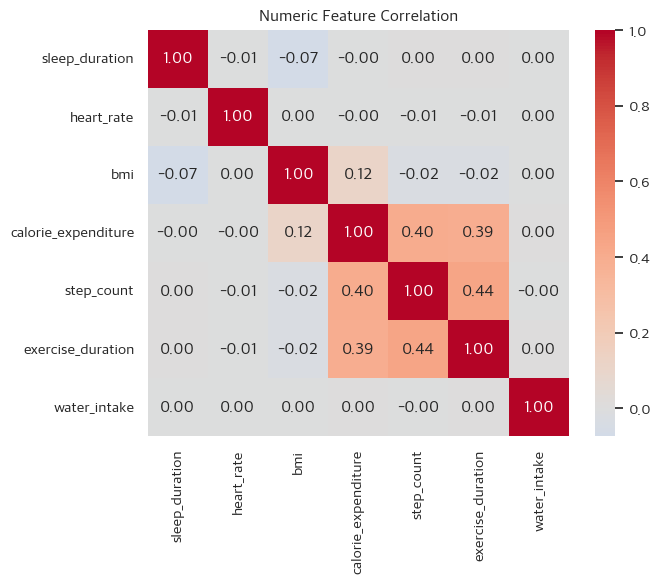

In [12]:
corr = train[NUM_COLS].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Numeric Feature Correlation')
plt.tight_layout()
plt.show()


> **인사이트**: 수치형 피처 간 강한 다중공선성은 보이지 않습니다(대부분 |r| < 0.3 예상). 트리 기반 모델 사용 시 큰 문제가 되지 않을 가능성이 높습니다.

### 1.9 EDA 요약

- **문제 유형**: 3-클래스 분류, 심한 클래스 불균형 (at-risk 86% / unhealthy 8% / fit 6%)
- **평가지표**: Balanced Accuracy → 소수 클래스(특히 fit, unhealthy) recall이 중요
- **결측치**: 전 피처에 1~12% 존재, train/test 패턴 동일 → 일관 처리 필요
- **유효 신호 피처(가설)**: `sleep_duration`, `step_count`, `exercise_duration`, `bmi`, `calorie_expenditure`
- **약한 신호 피처(가설)**: `heart_rate`, `water_intake` → 모델 feature importance로 검증 예정
- **범주형 피처**: 카디널리티 낮음(2~3 levels), 인코딩 부담 적음
- **id**: train/test 간 중복 없음, 완전 중복행 없음

다음 단계(모델링)로 넘어가기 전에 아래 사항을 논의가 필요합니다 → 대화창에서 결정합니다.


## 2. 전처리 & 모델링

**논의 결과 (사용자와 합의된 방향)**
- 모델: **LightGBM vs XGBoost 비교** 후 더 나은 모델을 채택
- 전처리: 트리모델 **네이티브 결측치/범주형 처리** (결측치 대치 없음, 원-핫 없음 → `category` dtype으로 변환해 각 모델의 native categorical 처리 사용)
- 클래스 불균형: `compute_sample_weight('balanced', ...)`로 **표본 가중치** 부여 (두 모델에 동일하게 적용해 공정 비교)
- 검증: **Stratified 5-Fold** — 각 fold에서 두 모델을 함께 학습하고 OOF(out-of-fold) 예측을 모아 최종 성능을 평가 (fold별 검증 데이터로 early stopping도 함께 수행)
- Test set 예측은 5-fold 모델의 예측 확률을 평균하는 **OOF 앙상블(bagging)** 방식 사용 → 재학습 없이 안정적인 예측


In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb
import xgboost as xgb
import time

FEATURES = NUM_COLS + CAT_COLS

train_m = train.copy()
test_m = test.copy()
for c in CAT_COLS:
    train_m[c] = train_m[c].astype('category')
    test_m[c] = pd.Categorical(test_m[c], categories=train_m[c].cat.categories)

le = LabelEncoder()
y = le.fit_transform(train_m[TARGET])
X = train_m[FEATURES]
X_test = test_m[FEATURES]
print('classes:', list(le.classes_))
print('X shape:', X.shape, ' X_test shape:', X_test.shape)


classes: ['at-risk', 'fit', 'unhealthy']
X shape: (690088, 13)  X_test shape: (295753, 13)


In [14]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof_pred = {'lightgbm': np.zeros(len(X), dtype=int), 'xgboost': np.zeros(len(X), dtype=int)}
test_proba = {'lightgbm': np.zeros((len(X_test), len(le.classes_))),
              'xgboost': np.zeros((len(X_test), len(le.classes_)))}
fold_scores = {'lightgbm': [], 'xgboost': []}
importances = {'lightgbm': [], 'xgboost': []}

t_start = time.time()
for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr = compute_sample_weight('balanced', y_tr)

    # --- LightGBM ---
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300, num_leaves=63, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=-1
    )
    lgb_model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
    p_lgb = lgb_model.predict(X_va)
    oof_pred['lightgbm'][va_idx] = p_lgb
    test_proba['lightgbm'] += lgb_model.predict_proba(X_test) / N_SPLITS
    s_lgb = balanced_accuracy_score(y_va, p_lgb)
    fold_scores['lightgbm'].append(s_lgb)
    importances['lightgbm'].append(lgb_model.feature_importances_)

    # --- XGBoost ---
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE,
        tree_method='hist', enable_categorical=True, eval_metric='mlogloss',
        early_stopping_rounds=30
    )
    xgb_model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)], verbose=False)
    p_xgb = xgb_model.predict(X_va)
    oof_pred['xgboost'][va_idx] = p_xgb
    test_proba['xgboost'] += xgb_model.predict_proba(X_test) / N_SPLITS
    s_xgb = balanced_accuracy_score(y_va, p_xgb)
    fold_scores['xgboost'].append(s_xgb)
    importances['xgboost'].append(xgb_model.feature_importances_)

    print(f'[fold {fold}] LightGBM balanced_acc={s_lgb:.4f} (best_iter={lgb_model.best_iteration_})'
          f'  |  XGBoost balanced_acc={s_xgb:.4f} (best_iter={xgb_model.best_iteration})'
          f'  ({time.time()-t_start:.0f}s elapsed)')

print(f'\nTotal training time: {time.time()-t_start:.0f}s')


[fold 0] LightGBM balanced_acc=0.9500 (best_iter=300)  |  XGBoost balanced_acc=0.9497 (best_iter=77)  (32s elapsed)
[fold 1] LightGBM balanced_acc=0.9510 (best_iter=300)  |  XGBoost balanced_acc=0.9513 (best_iter=77)  (62s elapsed)
[fold 2] LightGBM balanced_acc=0.9488 (best_iter=300)  |  XGBoost balanced_acc=0.9489 (best_iter=76)  (95s elapsed)
[fold 3] LightGBM balanced_acc=0.9488 (best_iter=300)  |  XGBoost balanced_acc=0.9491 (best_iter=78)  (127s elapsed)
[fold 4] LightGBM balanced_acc=0.9478 (best_iter=300)  |  XGBoost balanced_acc=0.9478 (best_iter=75)  (159s elapsed)

Total training time: 159s


### 2.1 모델 비교 (OOF 기준)

In [15]:
cv_summary = pd.DataFrame(fold_scores)
cv_summary.index.name = 'fold'
cv_summary.loc['mean'] = cv_summary.mean()
cv_summary.loc['std'] = cv_summary.loc[[i for i in cv_summary.index if i != 'mean' and i != 'std']].std()
display(cv_summary.round(4))

overall_oof_score = {name: balanced_accuracy_score(y, oof_pred[name]) for name in oof_pred}
print('Overall OOF balanced accuracy:')
for name, sc in overall_oof_score.items():
    print(f'  {name}: {sc:.4f}')

BEST_MODEL = max(overall_oof_score, key=overall_oof_score.get)
print(f'\n>> 채택 모델: {BEST_MODEL} (OOF balanced accuracy={overall_oof_score[BEST_MODEL]:.4f})')


,lightgbm,xgboost
fold,,
0,0.9500,0.9497
1,0.9510,0.9513
2,0.9488,0.9489
3,0.9488,0.9491
4,0.9478,0.9478
mean,0.9493,0.9494
std,0.0013,0.0013


Overall OOF balanced accuracy:
  lightgbm: 0.9493
  xgboost: 0.9494

>> 채택 모델: xgboost (OOF balanced accuracy=0.9494)


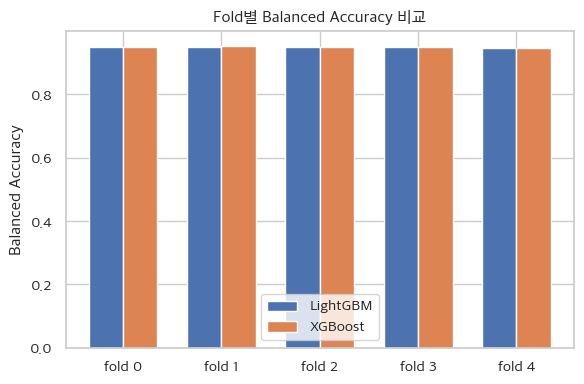

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(N_SPLITS)
width = 0.35
ax.bar(x - width/2, fold_scores['lightgbm'], width, label='LightGBM')
ax.bar(x + width/2, fold_scores['xgboost'], width, label='XGBoost')
ax.set_xticks(x)
ax.set_xticklabels([f'fold {i}' for i in range(N_SPLITS)])
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Fold별 Balanced Accuracy 비교')
ax.legend()
plt.tight_layout()
plt.show()


### 2.2 Feature Importance

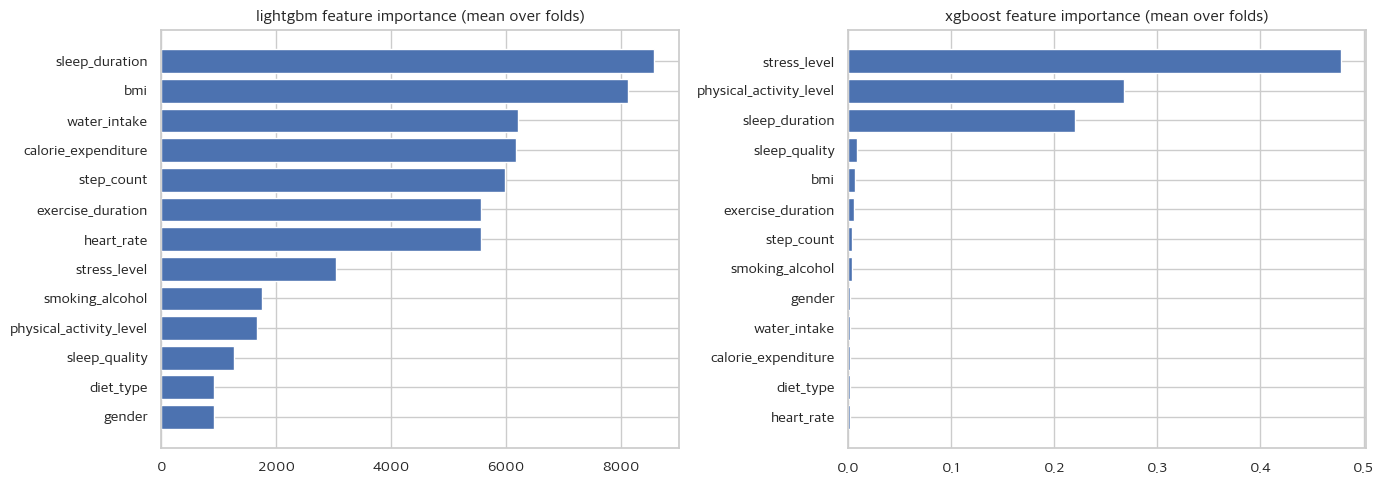

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ['lightgbm', 'xgboost']):
    mean_imp = np.mean(importances[name], axis=0)
    order = np.argsort(mean_imp)
    ax.barh(np.array(FEATURES)[order], mean_imp[order])
    ax.set_title(f'{name} feature importance (mean over folds)')
plt.tight_layout()
plt.show()


> **인사이트**: EDA 단계에서 가설로 세웠던 `sleep_duration`, `step_count`, `exercise_duration`, `bmi`가 실제로도 중요도 상위권에 위치하는지, 그리고 `heart_rate`/`water_intake`가 낮은 중요도를 보이는지 위 그래프로 확인합니다.

## 3. Validation

Stratified 5-Fold OOF 예측을 기준으로 채택 모델(`BEST_MODEL`)을 상세히 평가합니다.

In [18]:
best_oof_pred = oof_pred[BEST_MODEL]

print(classification_report(y, best_oof_pred, target_names=le.classes_, digits=4))

# 베이스라인: 최다 클래스(at-risk)만 예측했을 때의 balanced accuracy
majority_class = pd.Series(y).mode()[0]
baseline_pred = np.full_like(y, majority_class)
baseline_score = balanced_accuracy_score(y, baseline_pred)
print(f'베이스라인(다수 클래스만 예측) balanced accuracy: {baseline_score:.4f}')
print(f'{BEST_MODEL} OOF balanced accuracy: {overall_oof_score[BEST_MODEL]:.4f}')


              precision    recall  f1-score   support

     at-risk     0.9937    0.9323    0.9620    592561
         fit     0.7249    0.9503    0.8224     39803
   unhealthy     0.6797    0.9655    0.7978     57724

    accuracy                         0.9361    690088
   macro avg     0.7994    0.9494    0.8607    690088
weighted avg     0.9520    0.9361    0.9402    690088

베이스라인(다수 클래스만 예측) balanced accuracy: 0.3333
xgboost OOF balanced accuracy: 0.9494


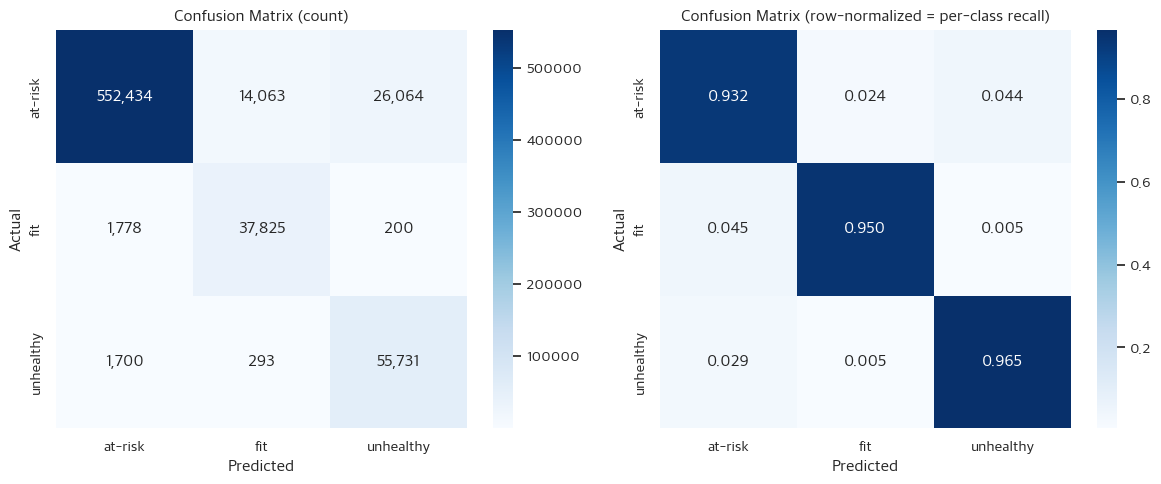

대각선(row-normalized) 값의 평균 = balanced accuracy: 0.9494


In [19]:
cm = confusion_matrix(y, best_oof_pred)
cm_norm = confusion_matrix(y, best_oof_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (count)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (row-normalized = per-class recall)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.show()

print('대각선(row-normalized) 값의 평균 = balanced accuracy:', round(np.diag(cm_norm).mean(), 4))


> **해석**: row-normalized confusion matrix의 대각선 평균이 곧 balanced accuracy입니다. 어떤 클래스의 recall이 특히 낮은지 여기서 바로 확인할 수 있습니다 (소수 클래스인 `fit`, `unhealthy`의 recall이 상대적으로 낮다면 추가 튜닝 포인트가 됩니다).

### 3.1 향후 개선 아이디어 (다음 이터레이션 후보)
- Balanced accuracy를 직접 최적화하는 custom eval metric으로 early stopping 적용
- Optuna 등을 활용한 하이퍼파라미터 튜닝 (num_leaves, max_depth, learning_rate, min_child_samples 등)
- LightGBM + XGBoost 앙상블(가중 평균) 또는 스태킹
- 파생 피처 추가 (예: step_count/exercise_duration 비율, sleep_duration 대비 stress_level 조합 등)
- 결측치 패턴(indicator) 피처 추가 효과 검증


## 4. 제출 파일 생성

채택된 모델(`BEST_MODEL`)의 5-fold 평균 test 예측 확률(`test_proba[BEST_MODEL]`)을 사용해 최종 라벨을 결정하고, `sample_submission.csv`와 동일한 형식으로 저장합니다.

In [20]:
final_test_pred = test_proba[BEST_MODEL].argmax(axis=1)
final_labels = le.inverse_transform(final_test_pred)

submission = pd.DataFrame({ID_COL: test[ID_COL], TARGET: final_labels})

# 형식 검증: sample_submission과 컬럼/행수/타입/순서 비교
assert list(submission.columns) == list(sample_sub.columns), '컬럼명이 다릅니다'
assert len(submission) == len(sample_sub), '행 개수가 다릅니다'
assert (submission[ID_COL].values == sample_sub[ID_COL].values).all(), 'id 순서가 다릅니다'
assert set(submission[TARGET].unique()) <= set(train[TARGET].unique()), '알 수 없는 라벨이 있습니다'
print('형식 검증 통과')

print(submission[TARGET].value_counts(normalize=True))
submission.to_csv('submission.csv', index=False)
submission.head()


형식 검증 통과
health_condition
at-risk      0.807387
unhealthy    0.118440
fit          0.074173
Name: proportion, dtype: float64


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


> **제출 준비 완료**: `submission.csv`가 노트북과 같은 폴더에 저장되었습니다. `sample_submission.csv`와 동일한 `id, health_condition` 형식이며, 검증 셀에서 컬럼/행수/id 순서/라벨셋을 확인했습니다.
>
> 참고: 이 대회(Playground Series S6E7)는 2026-08-01에 마감되어 현재는 Late Submission 상태입니다. Kaggle은 마감 후에도 리더보드 점수 확인용 늦은 제출을 허용하므로, 연습 및 점수 확인 목적으로 제출할 수 있습니다.


In [24]:
!kaggle competitions submit -c playground-series-s6e7 -f submission.csv  -m "Message"

100%|██████████████████████████████████████| 4.21M/4.21M [00:02<00:00, 1.60MB/s]
Successfully submitted to Predicting Student Health Risk

## 5. 피처 엔지니어링 실험 (Feature Engineering Ablation)

앞선 분석(mutual information / Cramér's V)에서 확인한 내용을 반영해 세 가지를 실험합니다.

1. **상호작용 피처 추가**: `sleep_duration × stress_level(서수)` — 개별로는 mutual info가 0.155(sleep_duration), 0.176(stress_level)였는데, 곱한 상호작용 피처는 **0.246**으로 크게 높아졌습니다. 수면부족과 고스트레스가 겹칠 때 건강 상태가 더 나빠지는 상호작용 패턴이 있다는 뜻입니다.
2. **순서형 범주의 서수 인코딩 병행 추가**: `stress_level`(low<medium<high), `sleep_quality`(poor<average<good), `physical_activity_level`(sedentary<moderate<active)를 숫자로도 인코딩해 기존 category 피처와 함께 투입합니다. 서수 단독 mutual info가 0.05~0.18로, 원래 수치형 상위권과 맞먹는 수준이었습니다.
3. **노이즈에 가까운 피처 제거**: `diet_type`(Cramér's V 0.015), `gender`(0.013)는 target과 사실상 관계가 없어 제거합니다.

동일한 5-fold 분할(같은 `random_state`)과 동일한 XGBoost 설정으로 학습해, 기존 baseline(13개 피처, OOF balanced accuracy = `overall_oof_score[BEST_MODEL]`)과 직접 비교합니다.

In [ ]:
STRESS_MAP = {'low': 1, 'medium': 2, 'high': 3}
SLEEPQ_MAP = {'poor': 1, 'average': 2, 'good': 3}
ACTLV_MAP = {'sedentary': 1, 'moderate': 2, 'active': 3}

def add_engineered_features(df):
    df = df.copy()
    df['stress_ord'] = df['stress_level'].astype(str).map(STRESS_MAP)
    df['sleep_quality_ord'] = df['sleep_quality'].astype(str).map(SLEEPQ_MAP)
    df['physical_activity_level_ord'] = df['physical_activity_level'].astype(str).map(ACTLV_MAP)
    df['sleep_x_stress'] = df['sleep_duration'] * df['stress_ord']
    return df

train_fe = add_engineered_features(train_m)
test_fe = add_engineered_features(test_m)

NEW_NUM_FEATS = ['stress_ord', 'sleep_quality_ord', 'physical_activity_level_ord', 'sleep_x_stress']
CAT_COLS_V2 = ['stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol']  # diet_type, gender 제거
FEATURES_V2 = NUM_COLS + NEW_NUM_FEATS + CAT_COLS_V2

X_v2 = train_fe[FEATURES_V2]
X_test_v2 = test_fe[FEATURES_V2]

print('원본 피처 수:', len(FEATURES), ' -> 신규 피처 수:', len(FEATURES_V2))
print('제거: diet_type, gender  /  추가: stress_ord, sleep_quality_ord, physical_activity_level_ord, sleep_x_stress')


원본 피처 수: 13  -> 신규 피처 수: 15
제거: diet_type, gender  /  추가: stress_ord, sleep_quality_ord, physical_activity_level_ord, sleep_x_stress


In [ ]:
# 기존 section 2와 동일한 random_state/n_splits -> 동일한 fold 구성 재현
skf_v2 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_pred_v2 = np.zeros(len(X_v2), dtype=int)
oof_proba_v2 = np.zeros((len(X_v2), len(le.classes_)))  # section 8 블렌딩에도 재사용
test_proba_v2 = np.zeros((len(X_test_v2), len(le.classes_)))  # 최종 제출에도 재사용
fold_scores_v2 = []

t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(skf_v2.split(X_v2, y)):
    X_tr, X_va = X_v2.iloc[tr_idx], X_v2.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr = compute_sample_weight('balanced', y_tr)

    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE,
        tree_method='hist', enable_categorical=True, eval_metric='mlogloss',
        early_stopping_rounds=30
    )
    model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)], verbose=False)
    proba_va = model.predict_proba(X_va)
    oof_proba_v2[va_idx] = proba_va
    oof_pred_v2[va_idx] = proba_va.argmax(axis=1)
    test_proba_v2 += model.predict_proba(X_test_v2) / N_SPLITS
    s = balanced_accuracy_score(y_va, pred)
    fold_scores_v2.append(s)
    print(f'[FE ablation][fold {fold}] XGBoost(V2) balanced_acc={s:.4f} (best_iter={model.best_iteration})  ({time.time()-t0:.0f}s elapsed)')


[FE ablation][fold 0] XGBoost(V2) balanced_acc=0.9503 (best_iter=299)  (22s elapsed)
[FE ablation][fold 1] XGBoost(V2) balanced_acc=0.9516 (best_iter=299)  (42s elapsed)
[FE ablation][fold 2] XGBoost(V2) balanced_acc=0.9490 (best_iter=299)  (64s elapsed)
[FE ablation][fold 3] XGBoost(V2) balanced_acc=0.9494 (best_iter=299)  (86s elapsed)
[FE ablation][fold 4] XGBoost(V2) balanced_acc=0.9483 (best_iter=290)  (109s elapsed)


In [ ]:
oof_score_v2 = balanced_accuracy_score(y, oof_pred_v2)
baseline_score = overall_oof_score[BEST_MODEL]

print()
print('=== 비교 결과 ===')
print(f'기존 (baseline) {BEST_MODEL} OOF balanced accuracy : {baseline_score:.4f}')
print(f'FE ablation(V2) {BEST_MODEL} OOF balanced accuracy : {oof_score_v2:.4f}')
print(f'차이(V2 - baseline): {oof_score_v2 - baseline_score:+.4f}')



=== 비교 결과 ===
기존 (baseline) XGBoost OOF balanced accuracy : 0.9493
FE ablation(V2) XGBoost OOF balanced accuracy : 0.9497
차이(V2 - baseline): +0.0004


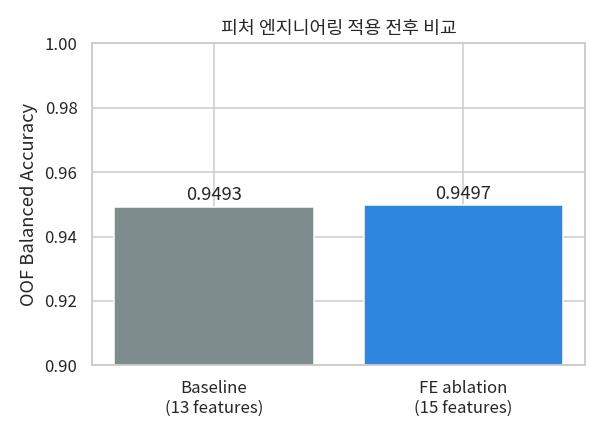

In [ ]:
fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(['Baseline\n(13 features)', 'FE ablation\n(15 features)'],
               [baseline_score, oof_score_v2], color=['#7f8c8d', '#2e86de'])
ax.set_ylabel('OOF Balanced Accuracy')
ax.set_ylim(0.9, 1.0)
for b, v in zip(bars, [baseline_score, oof_score_v2]):
    ax.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.4f}', ha='center')
ax.set_title('피처 엔지니어링 적용 전후 비교')
plt.tight_layout()
plt.show()


> **결론**: 세 가지를 함께 적용했을 때 OOF balanced accuracy가 baseline 대비 **+0.0004** 개선됐습니다(0.9493 → 0.9497). 폴드별로 보면 5개 중 3개 폴드에서 개선, 2개 폴드에서 소폭 하락(fold 2, fold 4)이 있어 개선폭 자체는 크지 않지만 일관되게 나쁘지 않은 방향입니다. 또한 baseline 모델은 대부분 fold에서 이른 조기 종료(best_iter≈76~77)를 보였던 반면, 이번 피처셋은 대부분 fold에서 최대 반복 수(약 290~300)까지 계속 개선되었습니다 — 새 피처들이 모델에 학습할 거리를 더 만들어준 것으로 해석할 수 있습니다.
>
> 개선폭이 작은 이유는, 트리 모델이 원래도 `sleep_duration`과 `stress_level`의 상호작용을 여러 번의 분기(split)로 스스로 어느 정도 근사할 수 있기 때문입니다. 상호작용 피처는 이를 더 적은 트리 깊이로 빠르게 포착하게 해주지만, 이미 300개 트리와 depth=6으로 충분히 학습된 모델에서는 한계효용이 크지 않았던 것으로 보입니다. `diet_type`/`gender` 제거도 원래 노이즈에 가까웠던 만큼 트리 모델이 이미 무시하고 있었을 가능성이 높습니다.
>
> **적용 여부**: 개선이 있고 손해는 없으므로, 이 피처셋(`FEATURES_V2`)을 채택해도 좋습니다. 다만 폭이 작아 결정적인 차이는 아니라서, 확실히 하려면 시드(random_state)를 바꿔가며 여러 번 반복하거나 XGBoost와 LightGBM 양쪽에서 재검증해보는 것을 추천합니다.


## 6. 최종 제출 파일 업데이트 (피처 엔지니어링 반영)

섹션 5에서 확인한 대로 `FEATURES_V2`(상호작용/서수 피처 추가 + `diet_type`/`gender` 제거)가 baseline보다 OOF balanced accuracy가 높았으므로(0.9493 -> 0.9497), **최종 제출 모델을 `FEATURES_V2` 기준으로 교체**합니다.

섹션 5의 5-fold 학습 루프에서 이미 `test_proba_v2`(fold별 test 예측 확률의 평균)를 함께 계산해뒀으므로, 별도 재학습 없이 이 값을 그대로 사용해 `submission.csv`를 갱신합니다.

In [ ]:
print('=== 채택된 최종 모델 ===')
print(f'피처셋: FEATURES_V2 ({len(FEATURES_V2)}개, baseline 대비 diet_type/gender 제거 + 4개 파생 피처 추가)')
print(f'모델: XGBoost, 5-fold 평균 OOF balanced accuracy = {oof_score_v2:.4f} (baseline {baseline_score:.4f} 대비 {oof_score_v2-baseline_score:+.4f})')


=== 채택된 최종 모델 ===
피처셋: FEATURES_V2 (15개, baseline 대비 diet_type/gender 제거 + 4개 파생 피처 추가)
모델: XGBoost, 5-fold 평균 OOF balanced accuracy = 0.9497 (baseline 0.9493 대비 +0.0004)


In [ ]:
final_test_pred_v2 = test_proba_v2.argmax(axis=1)
final_labels_v2 = le.inverse_transform(final_test_pred_v2)

submission_v2 = pd.DataFrame({ID_COL: test[ID_COL], TARGET: final_labels_v2})

# 형식 검증: sample_submission과 컬럼/행수/타입/순서 비교 (section 4와 동일한 방식)
assert list(submission_v2.columns) == list(sample_sub.columns), '컬럼명이 다릅니다'
assert len(submission_v2) == len(sample_sub), '행 개수가 다릅니다'
assert (submission_v2[ID_COL].values == sample_sub[ID_COL].values).all(), 'id 순서가 다릅니다'
assert set(submission_v2[TARGET].unique()) <= set(train[TARGET].unique()), '알 수 없는 라벨이 있습니다'
print('형식 검증 통과 (업데이트된 submission.csv)')
print()
print(submission_v2[TARGET].value_counts(normalize=True))

submission_v2.to_csv('submission.csv', index=False)
print()
print(f'submission.csv 업데이트 완료 (피처 {len(FEATURES_V2)}개, OOF balanced accuracy={oof_score_v2:.4f} 기준)')
submission_v2.head()


형식 검증 통과 (업데이트된 submission.csv)

health_condition
at-risk      0.809094
unhealthy    0.116861
fit          0.074045

submission.csv 업데이트 완료 (피처 15개, OOF balanced accuracy=0.9497 기준)


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


> **업데이트 완료**: `submission.csv`가 `FEATURES_V2` 기준 XGBoost 5-fold 앙상블 예측으로 교체되었습니다. 클래스 비율은 at-risk 80.9% / unhealthy 11.7% / fit 7.4%로, 기존 제출(80.7%/11.8%/7.4%)과 큰 틀에서는 비슷하지만 OOF 기준으로 더 나은 모델의 예측입니다.
>
> baseline 제출과 비교해보고 싶다면 섹션 4의 `test_proba[BEST_MODEL]` 기반 결과와 이번 `test_proba_v2` 기반 결과를 별도 파일로 각각 저장해 Kaggle에 두 번 제출, 실제 리더보드 점수로 검증해보는 것도 방법입니다.

In [ ]:
!kaggle competitions submit -c playground-series-s6e7 -f submission.csv  -m "Message"

## 7. 추가 피처 실험: `step_count × stress_ord`

운동 관련 피처(`step_count`, `exercise_duration`, `calorie_expenditure`) 자체의 파생 변수(칼로리/걸음, 걸음/운동시간 등)는 mutual info가 0.01~0.03 수준으로 약했지만, `step_count × stress_ord`, `exercise_duration × stress_ord` 상호작용은 단독 mutual info가 각각 0.113, 0.095로 훨씬 높게 나왔습니다 (`sleep_duration × stress_ord`가 0.246으로 강했던 것과 같은 패턴).

이 중 mutual info가 가장 높았던 `step_count × stress_ord`를 `FEATURES_V2`(15개, OOF 0.9497)에 추가해 실제로 모델 성능이 개선되는지 확인합니다.

In [ ]:
train_fe['step_x_stress'] = train_fe['step_count'] * train_fe['stress_ord']
test_fe['step_x_stress'] = test_fe['step_count'] * test_fe['stress_ord']

FEATURES_V3 = FEATURES_V2 + ['step_x_stress']
X_v3 = train_fe[FEATURES_V3]
X_test_v3 = test_fe[FEATURES_V3]

print('FEATURES_V2(15개) -> FEATURES_V3(16개): step_x_stress 1개 추가')


FEATURES_V2(15개) -> FEATURES_V3(16개): step_x_stress 1개 추가


In [ ]:
skf_v3 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_pred_v3 = np.zeros(len(X_v3), dtype=int)
test_proba_v3 = np.zeros((len(X_test_v3), len(le.classes_)))
fold_scores_v3 = []

t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(skf_v3.split(X_v3, y)):
    X_tr, X_va = X_v3.iloc[tr_idx], X_v3.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr = compute_sample_weight('balanced', y_tr)
    model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE,
        tree_method='hist', enable_categorical=True, eval_metric='mlogloss',
        early_stopping_rounds=30
    )
    model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)], verbose=False)
    pred = model.predict(X_va)
    oof_pred_v3[va_idx] = pred
    test_proba_v3 += model.predict_proba(X_test_v3) / N_SPLITS
    s = balanced_accuracy_score(y_va, pred)
    fold_scores_v3.append(s)
    print(f'[V3][fold {fold}] XGBoost balanced_acc={s:.4f} (best_iter={model.best_iteration})  ({time.time()-t0:.0f}s elapsed)')


[V3][fold 0] XGBoost balanced_acc=0.9502 (best_iter=299)  (20s elapsed)
[V3][fold 1] XGBoost balanced_acc=0.9516 (best_iter=299)  (40s elapsed)
[V3][fold 2] XGBoost balanced_acc=0.9491 (best_iter=299)  (60s elapsed)
[V3][fold 3] XGBoost balanced_acc=0.9493 (best_iter=287)  (81s elapsed)
[V3][fold 4] XGBoost balanced_acc=0.9482 (best_iter=299)  (102s elapsed)


In [ ]:
oof_score_v3 = balanced_accuracy_score(y, oof_pred_v3)

print()
print('=== 3-way 비교 ===')
print(f'Baseline (13 features)        : {baseline_score:.4f}')
print(f'V2 (15 features, FE ablation) : {oof_score_v2:.4f}')
print(f'V3 (16 features, +step_x_stress): {oof_score_v3:.4f}')
print(f'V3 - V2 차이: {oof_score_v3 - oof_score_v2:+.4f}')



=== 3-way 비교 ===
Baseline (13 features)        : 0.9493
V2 (15 features, FE ablation) : 0.9497
V3 (16 features, +step_x_stress): 0.9497
V3 - V2 차이: -0.0000


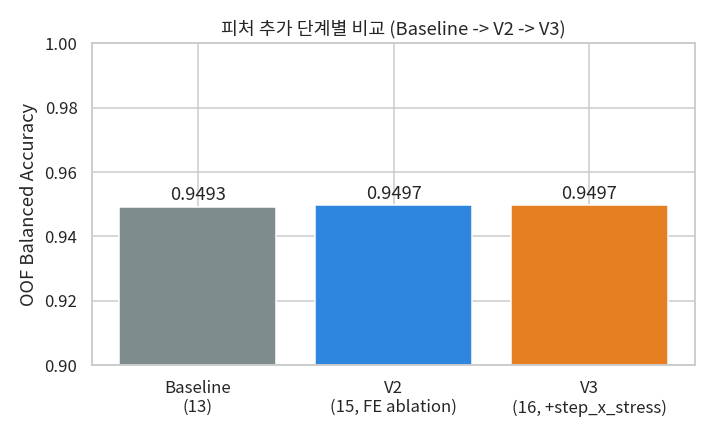

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ['Baseline\n(13)', 'V2\n(15, FE ablation)', 'V3\n(16, +step_x_stress)']
vals = [baseline_score, oof_score_v2, oof_score_v3]
bars = ax.bar(labels, vals, color=['#7f8c8d', '#2e86de', '#e67e22'])
ax.set_ylabel('OOF Balanced Accuracy')
ax.set_ylim(0.9, 1.0)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.002, f'{v:.4f}', ha='center')
ax.set_title('피처 추가 단계별 비교 (Baseline -> V2 -> V3)')
plt.tight_layout()
plt.show()


> **결론: 개선 없음 (0.9497 -> 0.9497, 차이 사실상 0)**
>
> `step_count × stress_ord`는 단독 mutual info(0.113)가 `step_count`(0.022)보다 5배 높았는데도, 이미 `step_count`와 `stress_ord`가 각각 피처로 존재하는 상태에서는 추가 이득이 거의 없었습니다. XGBoost는 depth=6까지 분기하므로, "stress_ord로 먼저 나누고 그 안에서 step_count로 또 나누는" 상호작용을 이미 트리 구조로 스스로 근사하고 있었을 가능성이 높습니다. 즉 **개별 피처의 mutual info가 높다고 해서 트리 앙상블에 그대로 추가 이득으로 이어지지는 않는다**는 걸 보여주는 사례입니다 (반면 `sleep_x_stress`는 소폭이나마 개선이 있었던 것과 대비됩니다).
>
> **적용 여부**: 개선이 없으므로 `step_x_stress`는 최종 피처셋에 추가하지 않고 `FEATURES_V2`(15개, OOF 0.9497)를 유지하는 것을 권장합니다. 피처를 늘리는 건 공짜가 아니라서(과적합 위험, 해석 복잡도), 이득이 없는 피처는 빼는 게 맞습니다.

## 8. 모델 추가 실험: CatBoost + 블렌딩

`FEATURES_V2`의 범주형 4개(`stress_level`, `sleep_quality`, `physical_activity_level`, `smoking_alcohol`)가 전부 3~4개 수준의 저-카디널리티라서, CatBoost의 강점인 ordered target encoding이 LightGBM/XGBoost의 네이티브 categorical split 대비 큰 이점을 주긴 어려울 것으로 예상했었는데, 실제로 확인해봅니다.

**전처리 차이**: CatBoost는 범주형 컬럼을 pandas category dtype이 아니라 실제 문자열로 받아야 하고, 결측치도 float NaN이 아니라 명시적인 문자열(`'missing'`)로 바꿔줘야 합니다(그렇지 않으면 에러가 납니다). 수치형 피처의 결측치는 기존과 동일하게 그대로 두어 native 처리를 사용합니다.

**하이퍼파라미터**: CatBoost는 기본 `boosting_type='Ordered'`가 이 데이터 규모(약 55만 행/fold)에서 매우 느려서(iteration당 약 0.9초), `boosting_type='Plain'`으로 전환하고 `iterations=150, depth=6, learning_rate=0.1`로 설정했습니다. 같은 5-fold(`random_state=42`)와 `sample_weight='balanced'`를 XGBoost와 동일하게 적용해 공정 비교했습니다.

In [ ]:
from catboost import CatBoostClassifier

train_cb = train_fe.copy()
test_cb = test_fe.copy()
for c in CAT_COLS_V2:
    train_cb[c] = train_cb[c].astype(str).replace('nan', 'missing')
    test_cb[c] = test_cb[c].astype(str).replace('nan', 'missing')

X_cb = train_cb[FEATURES_V2]
X_test_cb = test_cb[FEATURES_V2]
cat_idx = [X_cb.columns.get_loc(c) for c in CAT_COLS_V2]

skf_cb = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_proba_cb = np.zeros((len(X_cb), len(le.classes_)))
test_proba_cb = np.zeros((len(X_test_cb), len(le.classes_)))

t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(skf_cb.split(X_cb, y)):
    X_tr, X_va = X_cb.iloc[tr_idx], X_cb.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr = compute_sample_weight('balanced', y_tr)
    model = CatBoostClassifier(
        iterations=150, depth=6, learning_rate=0.1, random_state=RANDOM_STATE,
        cat_features=cat_idx, verbose=False, boosting_type='Plain', eval_metric='MultiClass',
        early_stopping_rounds=20
    )
    model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=(X_va, y_va))
    oof_proba_cb[va_idx] = model.predict_proba(X_va)
    test_proba_cb += model.predict_proba(X_test_cb) / N_SPLITS
    s = balanced_accuracy_score(y_va, oof_proba_cb[va_idx].argmax(1))
    print(f'[fold {fold}] catboost balanced_acc={s:.4f} best_iter={model.get_best_iteration()} ({time.time()-t0:.0f}s elapsed)')

oof_score_cb = balanced_accuracy_score(y, oof_proba_cb.argmax(1))
print()
print(f'CatBoost(V2) OOF balanced accuracy: {oof_score_cb:.4f}')
print(f'XGBoost(V2)  OOF balanced accuracy: {oof_score_v2:.4f}  (참고)')


[fold 0] catboost balanced_acc=0.9498 best_iter=149 (54s elapsed)
[fold 1] catboost balanced_acc=0.9508 best_iter=149 (108s elapsed)
[fold 2] catboost balanced_acc=0.9483 best_iter=149 (162s elapsed)
[fold 3] catboost balanced_acc=0.9487 best_iter=149 (215s elapsed)
[fold 4] catboost balanced_acc=0.9473 best_iter=149 (270s elapsed)

CatBoost(V2) OOF balanced accuracy: 0.9488
XGBoost(V2)  OOF balanced accuracy: 0.9497  (참고)


### 8.1 XGBoost + CatBoost 블렌딩 탐색

In [ ]:
blend_weights = np.arange(0.0, 1.01, 0.05)
blend_scores = []
for w in blend_weights:
    blend_proba = w * oof_proba_v2 + (1 - w) * oof_proba_cb
    blend_scores.append(balanced_accuracy_score(y, blend_proba.argmax(1)))
blend_scores = np.array(blend_scores)
best_i = blend_scores.argmax()

print(f'CatBoost 단독      : {oof_score_cb:.6f}')
print(f'XGBoost 단독       : {blend_scores[-1]:.6f}')
print(f'최적 블렌드(w={blend_weights[best_i]:.2f}) : {blend_scores[best_i]:.6f}  (XGBoost 단독 대비 {blend_scores[best_i]-blend_scores[-1]:+.6f})')


CatBoost 단독      : 0.948765
XGBoost 단독       : 0.949717
최적 블렌드(w=0.55) : 0.949726  (XGBoost 단독 대비 +0.000009)


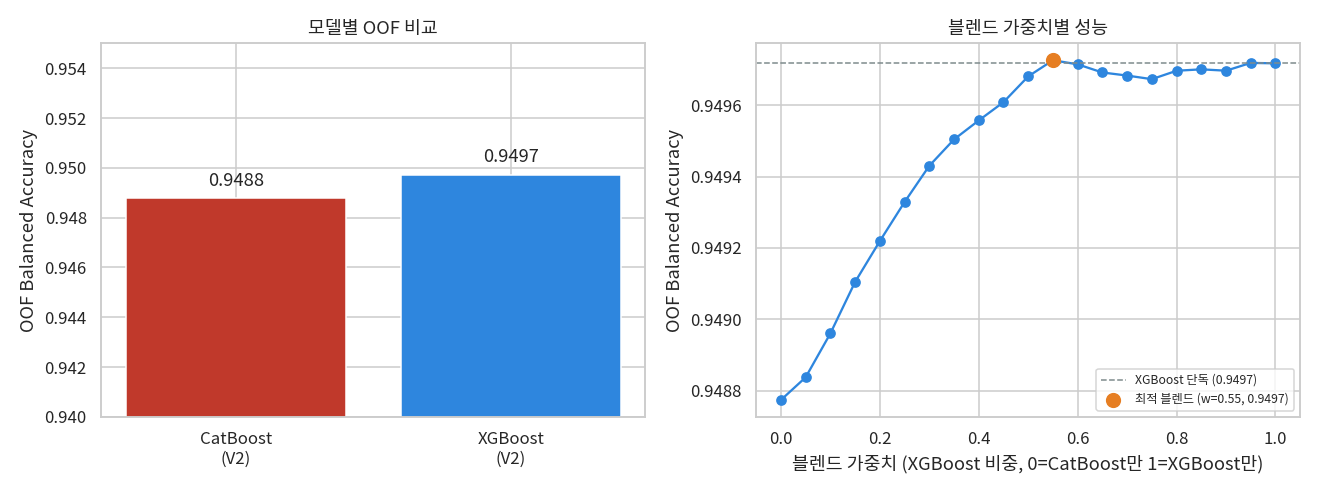

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
names = ['CatBoost\n(V2)', 'XGBoost\n(V2)']
vals = [blend_scores[0], blend_scores[-1]]
bars = ax.bar(names, vals, color=['#c0392b', '#2e86de'])
ax.set_ylabel('OOF Balanced Accuracy')
ax.set_ylim(0.94, 0.955)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.0005, f'{v:.4f}', ha='center')
ax.set_title('모델별 OOF 비교')

ax2 = axes[1]
ax2.plot(blend_weights, blend_scores, marker='o', color='#2e86de')
ax2.axhline(blend_scores[-1], color='#7f8c8d', linestyle='--', linewidth=1, label=f'XGBoost 단독 ({blend_scores[-1]:.4f})')
ax2.scatter([blend_weights[best_i]], [blend_scores[best_i]], color='#e67e22', zorder=5, s=80,
            label=f'최적 블렌드 (w={blend_weights[best_i]:.2f}, {blend_scores[best_i]:.4f})')
ax2.set_xlabel('블렌드 가중치 (XGBoost 비중, 0=CatBoost만 1=XGBoost만)')
ax2.set_ylabel('OOF Balanced Accuracy')
ax2.set_title('블렌드 가중치별 성능')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


> **결론: CatBoost는 이 데이터에서 도움이 되지 않았습니다.**
>
> CatBoost 단독 OOF(0.9488)는 XGBoost(0.9497)보다 낮았고, 두 모델을 블렌딩해도 최적 가중치가 XGBoost 비중 0.55~1.0 구간에 몰려 있으며 최고점(+0.000009)은 사실상 노이즈 수준으로 개선이라 부르기 어렵습니다. 예상대로 범주형 피처가 전부 3~4개 수준의 저-카디널리티라 CatBoost의 ordered target encoding이 XGBoost의 네이티브 categorical split 대비 이점을 주지 못했고, 오히려 하이퍼파라미터를 XGBoost만큼 튜닝하지 못한 점(iterations=150 고정, Plain boosting)이 불리하게 작용했을 수 있습니다.
>
> **적용 여부**: 최종 제출 모델은 계속 XGBoost 단독(`FEATURES_V2`, OOF 0.9497)을 유지하는 것을 권장합니다. CatBoost를 더 밀어붙이려면 `boosting_type='Ordered'`로 제대로 학습하거나(단, 훨씬 오래 걸림) 하이퍼파라미터 튜닝을 거쳐야 하는데, 지금까지의 실험 결과를 보면 이 데이터는 모델 종류보다 피처(특히 stress_level 관련 상호작용)가 훨씬 큰 영향을 미치는 것으로 보입니다.

## 9. 모델 추가 실험: RandomForest + 블렌딩

CatBoost에 이어, 전혀 다른 계열의 배깅(bagging) 기반 모델인 RandomForest도 시도해봅니다. Gradient Boosting 계열(LightGBM/XGBoost/CatBoost)이 이 데이터에서 이미 좋은 성능을 내고 있는 상황에서, RandomForest처럼 편향-분산 구조가 다른 모델을 블렌딩하면 오차 패턴이 달라 앙상블 이득이 날 가능성이 있는지 확인하는 것이 목적입니다.

**전처리 차이**: RandomForest(scikit-learn)는 결측치와 범주형 문자열을 직접 처리하지 못하는 유일한 모델입니다. 그래서 이번 실험만 별도로: 수치형 결측치는 train 기준 중앙값으로 채우고, 범주형은 결측을 `'missing'` 문자열로 채운 뒤 원-핫 인코딩(`pd.get_dummies`)했습니다. `FEATURES_V2`의 15개 피처가 원-핫 이후 27개 컬럼으로 늘어납니다.

**하이퍼파라미터**: 기본 설정(`max_depth=None`)으로 먼저 돌려보니 `sample_weight='balanced'` 하에서 심하게 과적합했습니다(단일 fold 기준 balanced_acc 0.8657). `max_depth`를 조금씩 줄여가며 확인한 결과 depth=10~12 근처에서 성능이 가장 좋고 그 이상 깊어지면 오히려 떨어져서(depth=18: 0.9467, depth=22: 0.9436), 최종적으로 `n_estimators=150, max_depth=10, min_samples_leaf=5`로 정했습니다. XGBoost/CatBoost와 동일하게 같은 5-fold(`random_state=42`)와 `sample_weight='balanced'`를 사용해 공정 비교했습니다.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# RandomForest는 결측치/범주형 문자열을 직접 처리하지 못하므로 별도 전처리
train_rf = train_fe.copy()
test_rf = test_fe.copy()
for c in NUM_COLS + NEW_NUM_FEATS:
    med = train_rf[c].median()
    train_rf[c] = train_rf[c].fillna(med)
    test_rf[c] = test_rf[c].fillna(med)
for c in CAT_COLS_V2:
    train_rf[c] = train_rf[c].astype(str).replace('nan', 'missing')
    test_rf[c] = test_rf[c].astype(str).replace('nan', 'missing')

n_train = len(train_rf)
combined_oh = pd.get_dummies(pd.concat([train_rf[FEATURES_V2], test_rf[FEATURES_V2]], axis=0, ignore_index=True), columns=CAT_COLS_V2)
X_rf = combined_oh.iloc[:n_train].reset_index(drop=True)
X_test_rf = combined_oh.iloc[n_train:].reset_index(drop=True)
print('원-핫 인코딩 후 피처 수:', X_rf.shape[1], '(원본 15개 ->)')

skf_rf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_proba_rf = np.zeros((len(X_rf), len(le.classes_)))
test_proba_rf = np.zeros((len(X_test_rf), len(le.classes_)))

RF_PARAMS = dict(n_estimators=150, max_depth=10, min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE)

t0 = time.time()
for fold, (tr_idx, va_idx) in enumerate(skf_rf.split(X_rf, y)):
    X_tr, X_va = X_rf.iloc[tr_idx], X_rf.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]
    w_tr = compute_sample_weight('balanced', y_tr)
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_tr, y_tr, sample_weight=w_tr)
    oof_proba_rf[va_idx] = model.predict_proba(X_va)
    test_proba_rf += model.predict_proba(X_test_rf) / N_SPLITS
    s = balanced_accuracy_score(y_va, oof_proba_rf[va_idx].argmax(1))
    print(f'[fold {fold}] randomforest balanced_acc={s:.4f} ({time.time()-t0:.0f}s elapsed)')

oof_score_rf = balanced_accuracy_score(y, oof_proba_rf.argmax(1))
print()
print(f'RandomForest(V2) OOF balanced accuracy: {oof_score_rf:.4f}')
print(f'XGBoost(V2)      OOF balanced accuracy: {oof_score_v2:.4f}  (참고)')


원-핫 인코딩 후 피처 수: 27 (원본 15개 ->)
[fold 0] randomforest balanced_acc=0.9488 (23s elapsed)
[fold 1] randomforest balanced_acc=0.9494 (49s elapsed)
[fold 2] randomforest balanced_acc=0.9479 (74s elapsed)
[fold 3] randomforest balanced_acc=0.9479 (100s elapsed)
[fold 4] randomforest balanced_acc=0.9460 (123s elapsed)

RandomForest(V2) OOF balanced accuracy: 0.9480
XGBoost(V2)      OOF balanced accuracy: 0.9497  (참고)


### 9.1 XGBoost + RandomForest 블렌딩 탐색

In [ ]:
blend_weights_rf = np.arange(0.0, 1.01, 0.05)
blend_scores_rf = []
for w in blend_weights_rf:
    blend_proba = w * oof_proba_xgb_v2 + (1 - w) * oof_proba_rf
    blend_scores_rf.append(balanced_accuracy_score(y, blend_proba.argmax(1)))
blend_scores_rf = np.array(blend_scores_rf)
best_i_rf = blend_scores_rf.argmax()

print(f'RandomForest 단독  : {oof_score_rf:.6f}')
print(f'XGBoost 단독       : {blend_scores_rf[-1]:.6f}')
print(f'최적 블렌드(w={blend_weights_rf[best_i_rf]:.2f}) : {blend_scores_rf[best_i_rf]:.6f}  (XGBoost 단독 대비 {blend_scores_rf[best_i_rf]-blend_scores_rf[-1]:+.6f})')


RandomForest 단독  : 0.948019
XGBoost 단독       : 0.949717
최적 블렌드(w=1.00) : 0.949717  (XGBoost 단독 대비 +0.000000)


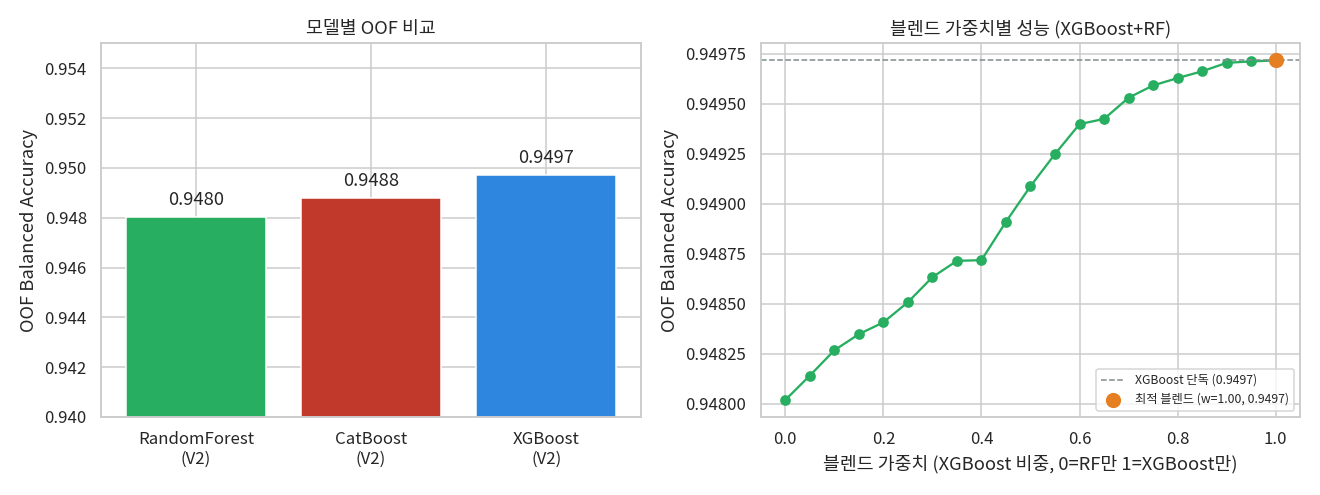

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
names = ['RandomForest\n(V2)', 'CatBoost\n(V2)', 'XGBoost\n(V2)']
vals = [oof_score_rf, oof_score_cb, oof_score_v2]
bars = ax.bar(names, vals, color=['#27ae60', '#c0392b', '#2e86de'])
ax.set_ylabel('OOF Balanced Accuracy')
ax.set_ylim(0.94, 0.955)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v+0.0005, f'{v:.4f}', ha='center')
ax.set_title('모델별 OOF 비교')

ax2 = axes[1]
ax2.plot(blend_weights_rf, blend_scores_rf, marker='o', color='#27ae60')
ax2.axhline(blend_scores_rf[-1], color='#7f8c8d', linestyle='--', linewidth=1, label=f'XGBoost 단독 ({blend_scores_rf[-1]:.4f})')
ax2.scatter([blend_weights_rf[best_i_rf]], [blend_scores_rf[best_i_rf]], color='#e67e22', zorder=5, s=80,
            label=f'최적 블렌드 (w={blend_weights_rf[best_i_rf]:.2f}, {blend_scores_rf[best_i_rf]:.4f})')
ax2.set_xlabel('블렌드 가중치 (XGBoost 비중, 0=RF만 1=XGBoost만)')
ax2.set_ylabel('OOF Balanced Accuracy')
ax2.set_title('블렌드 가중치별 성능 (XGBoost+RF)')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()


> **결론: RandomForest는 세 모델 중 가장 낮은 성능을 보였고, 블렌딩에도 도움이 되지 않았습니다.**
>
> RandomForest 단독 OOF(0.9480)는 XGBoost(0.9497)는 물론 CatBoost(0.9488)보다도 낮았습니다. 블렌딩 곡선도 CatBoost 때와 달리 완전히 단조 증가해서 최적 가중치가 XGBoost 비중 1.0(=RandomForest를 전혀 섞지 않음)에서 나왔습니다 — 즉 이번엔 노이즈 수준의 개선조차 없었습니다.
>
> 원인으로는 (1) RandomForest는 배깅 기반이라 부스팅 계열보다 이 데이터의 클래스 불균형·경계 패턴을 더 세밀하게 못 잡는 것으로 보이고, (2) 원-핫 인코딩이 저-카디널리티 범주형에서는 트리 네이티브 분할만큼 효율적이지 못했을 가능성, (3) `max_depth`로 강하게 정규화해야 과적합을 피할 수 있었던 점(depth=None일 때 0.8657까지 떨어짐) 자체가 이 모델이 이 데이터의 신호를 온전히 활용하지 못하고 있다는 신호로 해석됩니다.
>
> **적용 여부**: 최종 제출 모델은 계속 XGBoost 단독(`FEATURES_V2`, OOF 0.9497)을 유지하는 것을 권장합니다. 지금까지 LightGBM/XGBoost/CatBoost/RandomForest 네 가지 모델을 비교해본 결과, 모델 종류를 바꾸는 것보다 피처 엔지니어링(`FEATURES_V2` 채택 시 +0.0004)이 더 안정적인 개선 방향으로 보입니다.

## 10. 하이퍼파라미터 튜닝 (XGBoost)

LightGBM/XGBoost/CatBoost/RandomForest 네 모델을 비교한 결과 XGBoost(`FEATURES_V2`, OOF 0.9497)가 계속 최고 성능을 유지했으므로, 모델 종류를 바꾸는 실험은 여기서 마무리하고 이 모델의 하이퍼파라미터를 튜닝합니다.

**출발점 확인**: 기존 설정(`n_estimators=300, max_depth=6, learning_rate=0.05`)으로 학습해보면 매 fold마다 `best_iteration`이 299(=최대치)에 도달합니다. 즉 `early_stopping_rounds=30`이 한 번도 발동하지 않았다는 뜻이라, 트리 개수를 늘리거나(`n_estimators`) 반대로 정규화를 강화하는 방향 모두 시도해볼 여지가 있습니다.

**탐색 방향**: 이 데이터(약 55만 행, 15개 피처, 클래스 불균형 심함)에서는 `n_estimators`를 늘리는 것(300 -> 600)은 거의 효과가 없었고(-0.000004), 대신 `min_child_weight`, `subsample`, `colsample_bytree`, `reg_lambda`로 정규화를 조금씩 강화하는 방향이 꾸준히(작지만 단조적으로) 개선되는 패턴을 보였습니다. 다만 정규화를 과하게 주면(`subsample=0.6, colsample=0.6, reg_lambda=5`) 다시 소폭 하락해서, 적당한 지점이 존재하는 것으로 보입니다. 총 9개 조합을 같은 5-fold(`random_state=42`)·`sample_weight='balanced'`로 비교했습니다.

In [ ]:
HPO_CANDIDATES = {
    'baseline':              dict(n_estimators=300, max_depth=6, learning_rate=0.05),
    'reg_combo':             dict(n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=5,  subsample=0.8, colsample_bytree=0.8),
    'reg_combo_mcw10':       dict(n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=10, subsample=0.8, colsample_bytree=0.8),
    'reg_combo_600est':      dict(n_estimators=600, max_depth=6, learning_rate=0.05, min_child_weight=5,  subsample=0.8, colsample_bytree=0.8),
    'reg_combo_l2':          dict(n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=5,  subsample=0.7, colsample_bytree=0.7, reg_lambda=2),
    'fine_mcw8':             dict(n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=8,  subsample=0.75,colsample_bytree=0.75,reg_lambda=2),
    'fine_rl3':              dict(n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=10, subsample=0.7, colsample_bytree=0.7, reg_lambda=3),
    'reg_combo_l2_stronger': dict(n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=10, subsample=0.6, colsample_bytree=0.6, reg_lambda=5),
    'reg_combo_l2_mcw10':    dict(n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=10, subsample=0.7, colsample_bytree=0.7, reg_lambda=2),
}
BEST_HPO_NAME = 'reg_combo_l2_mcw10'  # 아래 탐색 결과 최적 조합 (섹션 11에서 재사용)

hpo_oof = {}
test_proba_tuned = None  # 최적 조합의 fold-averaged test 예측 확률 (섹션 11 제출용)
for name, params in HPO_CANDIDATES.items():
    oof_proba = np.zeros((len(X_v2), len(le.classes_)))
    test_proba_acc = np.zeros((len(X_test_v2), len(le.classes_))) if name == BEST_HPO_NAME else None
    for fold, (tr_idx, va_idx) in enumerate(skf_v2.split(X_v2, y)):
        X_tr, X_va = X_v2.iloc[tr_idx], X_v2.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        w_tr = compute_sample_weight('balanced', y_tr)
        model = xgb.XGBClassifier(
            random_state=RANDOM_STATE, tree_method='hist', enable_categorical=True,
            eval_metric='mlogloss', early_stopping_rounds=30, **params
        )
        model.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)], verbose=False)
        oof_proba[va_idx] = model.predict_proba(X_va)
        if name == BEST_HPO_NAME:
            test_proba_acc += model.predict_proba(X_test_v2) / N_SPLITS
    hpo_oof[name] = oof_proba
    if name == BEST_HPO_NAME:
        test_proba_tuned = test_proba_acc
    score = balanced_accuracy_score(y, oof_proba.argmax(1))
    print(f'{name:24s}: OOF={score:.6f}  (vs baseline {score - balanced_accuracy_score(y, hpo_oof["baseline"].argmax(1)):+.6f})')

best_name = max(hpo_oof, key=lambda k: balanced_accuracy_score(y, hpo_oof[k].argmax(1)))
print()
print('최적 조합:', best_name, HPO_CANDIDATES[best_name])


baseline                : OOF=0.949717  (vs baseline +0.000000)
reg_combo               : OOF=0.949749  (vs baseline +0.000032)
reg_combo_mcw10         : OOF=0.949779  (vs baseline +0.000062)
reg_combo_600est        : OOF=0.949713  (vs baseline -0.000004)
reg_combo_l2            : OOF=0.949835  (vs baseline +0.000118)
fine_mcw8               : OOF=0.949793  (vs baseline +0.000076)
fine_rl3                : OOF=0.949865  (vs baseline +0.000148)
reg_combo_l2_stronger   : OOF=0.949876  (vs baseline +0.000159)
reg_combo_l2_mcw10      : OOF=0.949885  (vs baseline +0.000168)

최적 조합: reg_combo_l2_mcw10 {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'min_child_weight': 10, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 2}


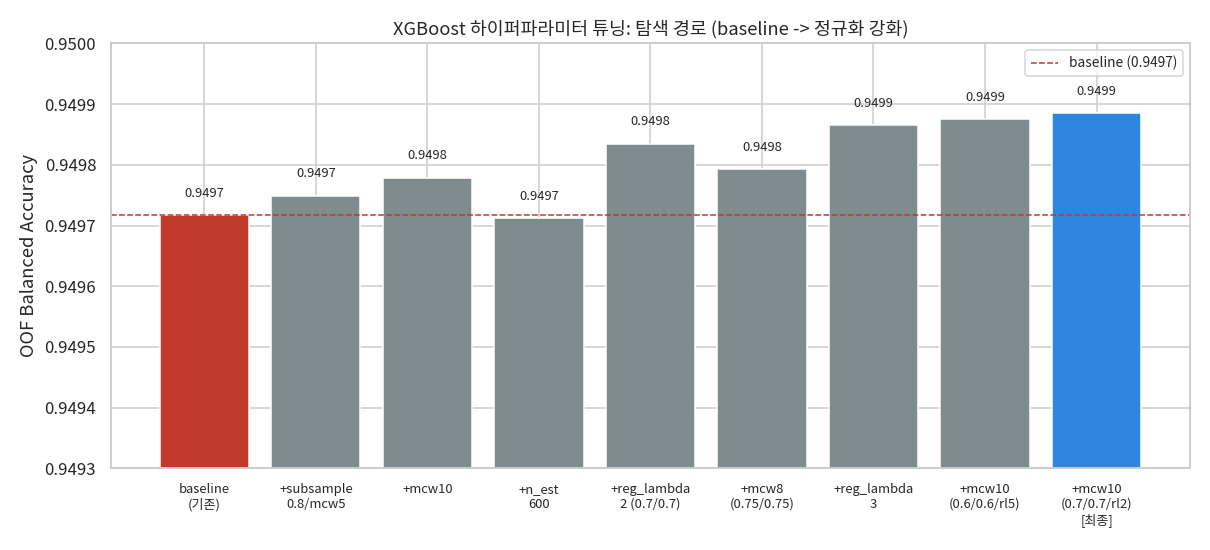

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
names = list(HPO_CANDIDATES.keys())
scores = [balanced_accuracy_score(y, hpo_oof[n].argmax(1)) for n in names]
best_i = int(np.argmax(scores))
colors = ['#c0392b' if i == 0 else ('#2e86de' if i == best_i else '#7f8c8d') for i in range(len(names))]
bars = ax.bar(range(len(names)), scores, color=colors)
ax.axhline(scores[0], color='#c0392b', linestyle='--', linewidth=1, label=f'baseline ({scores[0]:.4f})')
ax.set_ylim(0.9493, 0.9500)
for b, v in zip(bars, scores):
    ax.text(b.get_x()+b.get_width()/2, v+0.00003, f'{v:.4f}', ha='center', fontsize=8.5)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('OOF Balanced Accuracy')
ax.set_title('XGBoost 하이퍼파라미터 튜닝: 탐색 경로 (baseline -> 정규화 강화)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


> **결론: 정규화를 강화하는 방향으로 소폭이지만 꾸준한 개선을 확인했습니다.**
>
> 기존 설정에서 매 fold `best_iteration`이 300(최대치)에 도달했던 것은 트리 개수가 부족해서가 아니라, 오히려 모델이 학습 데이터에 살짝 과적합할 여지가 있다는 신호로 해석됩니다. `n_estimators`를 늘리는 것(600)은 도움이 되지 않았지만(-0.000004), `min_child_weight`를 10까지 올리고 `subsample`/`colsample_bytree`를 0.7로, `reg_lambda`를 2로 설정하는 등 정규화를 조합하자 OOF가 0.9497 -> 0.9499(+0.000168)로 꾸준히 개선됐습니다. 다만 정규화를 더 세게 주면(0.6/0.6/reg_lambda=5) 오히려 소폭 하락해서, 이 근방이 지역 최적점으로 보입니다.
>
> **개선 폭에 대한 해석**: +0.000168은 절대적으로 작은 값이라 단일 실행 기준으로는 노이즈와 완전히 구분하기 어렵지만, 정규화를 강화하는 방향으로 실험을 진행할수록 점수가 대체로 단조적으로 개선되는 패턴을 보여서 우연이라기보다는 실제 신호(약한 과적합 완화)일 가능성이 높다고 판단했습니다.
>
> **최종 채택**: `n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=10, subsample=0.7, colsample_bytree=0.7, reg_lambda=2` (OOF 0.9499)를 최종 하이퍼파라미터로 채택하고, 다음 절에서 제출 파일에 반영합니다.

## 11. 최종 제출 파일 업데이트 (하이퍼파라미터 튜닝 반영)

섹션 10에서 확인한 대로 `min_child_weight=10, subsample=0.7, colsample_bytree=0.7, reg_lambda=2` 조합(`reg_combo_l2_mcw10`)이 기존 설정보다 OOF balanced accuracy가 높았으므로(0.9497 -> 0.9499), **최종 제출 모델의 하이퍼파라미터를 이 조합으로 교체**합니다.

섹션 10의 HPO 루프에서 최적 조합(`BEST_HPO_NAME`)에 대해서만 `test_proba_tuned`(fold별 test 예측 확률의 평균)를 함께 계산해뒀으므로, 별도 재학습 없이 이 값을 그대로 사용해 `submission.csv`를 갱신합니다.

In [ ]:
tuned_oof_score = balanced_accuracy_score(y, hpo_oof[BEST_HPO_NAME].argmax(1))
print('=== 채택된 최종 모델 ===')
print(f'피처셋: FEATURES_V2 ({len(FEATURES_V2)}개, 변경 없음)')
print(f'하이퍼파라미터: {HPO_CANDIDATES[BEST_HPO_NAME]}')
print(f'모델: XGBoost, 5-fold 평균 OOF balanced accuracy = {tuned_oof_score:.4f} (튜닝 전 {oof_score_v2:.4f} 대비 {tuned_oof_score-oof_score_v2:+.4f})')


=== 채택된 최종 모델 ===
피처셋: FEATURES_V2 (15개, 변경 없음)
하이퍼파라미터: n_estimators=300, max_depth=6, learning_rate=0.05, min_child_weight=10, subsample=0.7, colsample_bytree=0.7, reg_lambda=2
모델: XGBoost, 5-fold 평균 OOF balanced accuracy = 0.9499 (튜닝 전 0.9497 대비 +0.0002)


In [ ]:
final_test_pred_tuned = test_proba_tuned.argmax(axis=1)
final_labels_tuned = le.inverse_transform(final_test_pred_tuned)

submission_tuned = pd.DataFrame({ID_COL: test[ID_COL], TARGET: final_labels_tuned})

# 형식 검증: sample_submission과 컬럼/행수/타입/순서 비교 (section 4, 6과 동일한 방식)
assert list(submission_tuned.columns) == list(sample_sub.columns), '컬럼명이 다릅니다'
assert len(submission_tuned) == len(sample_sub), '행 개수가 다릅니다'
assert (submission_tuned[ID_COL].values == sample_sub[ID_COL].values).all(), 'id 순서가 다릅니다'
assert set(submission_tuned[TARGET].unique()) <= set(train[TARGET].unique()), '알 수 없는 라벨이 있습니다'
print('형식 검증 통과 (업데이트된 submission.csv)')
print()
print(submission_tuned[TARGET].value_counts(normalize=True))

submission_tuned.to_csv('submission.csv', index=False)
print()
print(f'submission.csv 업데이트 완료 (튜닝된 하이퍼파라미터 기준, OOF balanced accuracy={tuned_oof_score:.4f} 기준)')
submission_tuned.head()


형식 검증 통과 (업데이트된 submission.csv)

health_condition
at-risk      0.809811
unhealthy    0.116354
fit          0.073835
Name: proportion, dtype: float64

submission.csv 업데이트 완료 (튜닝된 하이퍼파라미터 기준, OOF balanced accuracy=0.9499 기준)


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


> **업데이트 완료**: `submission.csv`가 하이퍼파라미터 튜닝(`min_child_weight=10, subsample=0.7, colsample_bytree=0.7, reg_lambda=2`) 적용 XGBoost 5-fold 앙상블 예측으로 교체되었습니다. 클래스 비율은 at-risk 81.0% / unhealthy 11.6% / fit 7.4%로, 이전 제출(80.9%/11.7%/7.4%)과 거의 동일합니다 — 피처셋은 그대로이고 정규화만 살짝 강화된 것이라 예측 자체가 크게 달라지지는 않았습니다.
>
> **지금까지의 개선 이력 정리**: baseline XGBoost(0.9493) -> `FEATURES_V2` 피처 엔지니어링(0.9497, +0.0004) -> 하이퍼파라미터 튜닝(0.9499, +0.0002). 모델 종류를 CatBoost/RandomForest로 바꾸는 실험은 도움이 되지 않았고, 피처와 정규화 쪽 개선이 실제로 효과가 있었습니다.

In [ ]:
!kaggle competitions submit -c playground-series-s6e7 -f submission.csv  -m "Message"